Computed roots:
  n     x(n) x(n) [4 s.f.]  iterations     residual
  5 1.780038          1.78           7 7.993606e-15
 10 1.923584         1.924           6 1.776357e-15
 15 1.990253          1.99           5 3.552714e-15
 20 2.032137         2.032           5 3.907985e-14
 25 2.062093         2.062           6 3.907985e-14
 30 2.085140         2.085           7 5.329071e-14
 35 2.103724         2.104           7 2.913225e-13
 40 2.119208         2.119           8 1.421085e-14
 45 2.132426         2.132           8 0.000000e+00
 50 2.143919         2.144           9 2.842171e-14
 55 2.154062         2.154           9 7.105427e-15
 60 2.163120         2.163          10 7.105427e-14
 65 2.171289         2.171          11 2.842171e-13
 70 2.178718         2.179          12 1.421085e-13
 75 2.185522         2.186          13 1.563194e-13
 80 2.191791         2.192          14 1.705303e-13
 85 2.197599         2.198          16 9.947598e-14
 90 2.203005         2.203          17 0.000000e

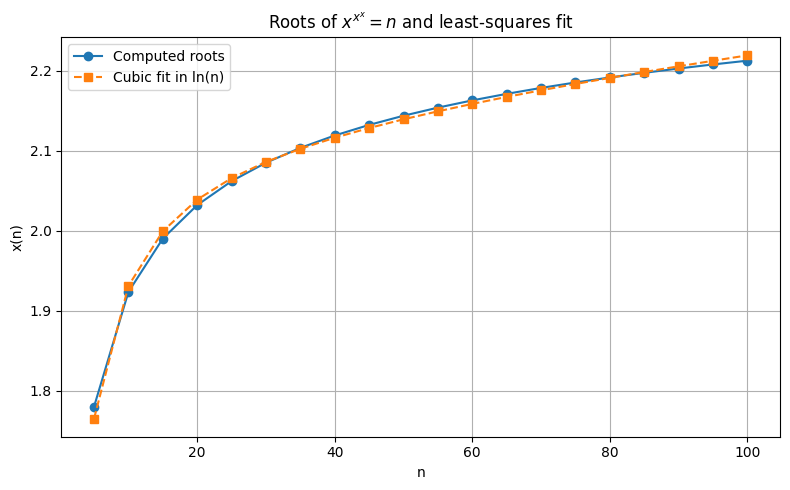

In [3]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# Part 1: Solve x^(x^x) = n using Newton's method

def f_root(x: float, n: float) -> float:
    """
    Nonlinear equation:
        f(x) = x^(x^x) - n
    """
    return x ** (x ** x) - n


def df_root(x: float) -> float:
    """
    Derivative of f(x) = x^(x^x) - n

    f'(x) = x^(x^x) * x^x * [ (ln x + 1) ln x + 1/x ]
    """
    if x <= 0:
        raise ValueError("x must be positive because ln(x) is required.")

    xx = x ** x
    x_to_xx = x ** xx
    logx = math.log(x)

    return x_to_xx * xx * ((logx + 1.0) * logx + 1.0 / x)


def newton_solve_for_n(
    n: float,
    x0: float = 2.0,
    tol: float = 1e-12,
    max_iter: int = 100
):
    """
    Solve x^(x^x) = n by Newton's method.

    Returns
    -------
    x : float
        Computed root
    iters : int
        Number of iterations used
    residual : float
        Absolute residual |f(x)|
    """
    x = x0

    for k in range(1, max_iter + 1):
        fx = f_root(x, n)
        dfx = df_root(x)

        if abs(fx) < tol:
            return x, k, abs(fx)

        x_new = x - fx / dfx

        if abs(x_new - x) < tol * max(1.0, abs(x_new)):
            x = x_new
            return x, k, abs(f_root(x, n))

        x = x_new

    return x, max_iter, abs(f_root(x, n))


def solve_multiple_n(
    n_values,
    x0: float = 2.0,
    tol: float = 1e-12,
    max_iter: int = 100
) -> pd.DataFrame:
    """
    Solve for multiple values of n and return a table.
    """
    records = []

    for n in n_values:
        root, iters, residual = newton_solve_for_n(
            n=n, x0=x0, tol=tol, max_iter=max_iter
        )
        records.append({
            "n": n,
            "x(n)": root,
            "x(n) [4 s.f.]": f"{root:.4g}",
            "iterations": iters,
            "residual": residual
        })

    return pd.DataFrame(records)


# Part 2: Least squares fitting

def build_design_matrix(n_values):
    """
    Construct A matrix with columns:
        ln(n), (ln n)^2, (ln n)^3
    """
    z = np.log(np.asarray(n_values, dtype=float))
    A = np.column_stack([z, z**2, z**3])
    return A


def fit_model(n_values, x_values):
    """
    Least squares fit for:
        x(n) = 1 + a1 ln(n) + a2 (ln n)^2 + a3 (ln n)^3

    """
    A = build_design_matrix(n_values)
    b = np.asarray(x_values, dtype=float) - 1.0

    normal_matrix = A.T @ A
    normal_rhs = A.T @ b

    coeffs = np.linalg.solve(normal_matrix, normal_rhs)
    fitted = 1.0 + A @ coeffs

    return coeffs, A, b, normal_matrix, normal_rhs, fitted


# Main execution

if __name__ == "__main__":
    # n = 5, 10, 15, ..., 100
    n_values = np.arange(5, 101, 5)

    # Part 1: solve roots
    df_results = solve_multiple_n(n_values, x0=2.0, tol=1e-12, max_iter=100)
    print("Computed roots:")
    print(df_results.to_string(index=False))

    # Part 2: fit model
    x_values = df_results["x(n)"].to_numpy()
    coeffs, A, b, ATA, ATb, fitted = fit_model(n_values, x_values)

    a1, a2, a3 = coeffs
    print("\nLeast-squares coefficients:")
    print(f"a1 = {a1:.10f}")
    print(f"a2 = {a2:.10f}")
    print(f"a3 = {a3:.10f}")

    print("\nNormal equations:")
    print("A^T A =")
    print(ATA)
    print("\nA^T b =")
    print(ATb)

    # Add fitted values and errors to table
    df_results["fitted x(n)"] = fitted
    df_results["fit error"] = df_results["x(n)"] - df_results["fitted x(n)"]

    print("\nResults with fitted values:")
    print(df_results.to_string(index=False))

    # Plot
    plt.figure(figsize=(8, 5))
    plt.plot(n_values, x_values, "o-", label="Computed roots")
    plt.plot(n_values, fitted, "s--", label="Cubic fit in ln(n)")
    plt.xlabel("n")
    plt.ylabel("x(n)")
    plt.title(r"Roots of $x^{x^x}=n$ and least-squares fit")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()